# Assignment 4: Regularization 

In [28]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. It makes the model more simple, so that it focuses on only certain parameters so the model is not super sensitive.
2. Regularization allows you to have low bias in return for less variance, making the model more stable instead of picking low bias or low variance.
3. LASSO can make all the coefficients turn to zero, while ridge can can shrink coefficients toward zero without eliminating them. 
4. We scale variables by subtracting the mean and dividing by standard deviation. This makes the mean = 0 and standard deviation = 1.
5. It is typically selected through cross validation. 
6. No, because the penalty is used to shape the model, so it is left out during evaluation to measure how accurately the model actually predicts real data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [17]:
print('2.1')
df = pd.read_csv('./data/cars_hw.csv')
df.head()

2.1


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [21]:
df['Age'] = 2026 - df['Make_Year']

# 2.1 a
X = df[['Mileage_Run', 'Age']]
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# 2.1 b
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [23]:
print('2.2')
ols = LinearRegression()
ols.fit(X_scaled, df['Price'])

interaction_idx = list(feature_names).index('Mileage_Run Age')
interaction_coef = ols.coef_[interaction_idx]

print(f"Interaction Coefficient: {interaction_coef}")

2.2
Interaction Coefficient: -1671212.3563918832


The sign for the interaction between `Mileage_Run` and `Age` is negative.

In [24]:
print('2.3')
alphas_grid = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas_grid, cv=20)
lasso_cv.fit(X_scaled, df['Price'])

print(f"Optimal Alpha: {lasso_cv.alpha_}")

2.3
Optimal Alpha: 69.51927961775606


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.462e+12

2.4


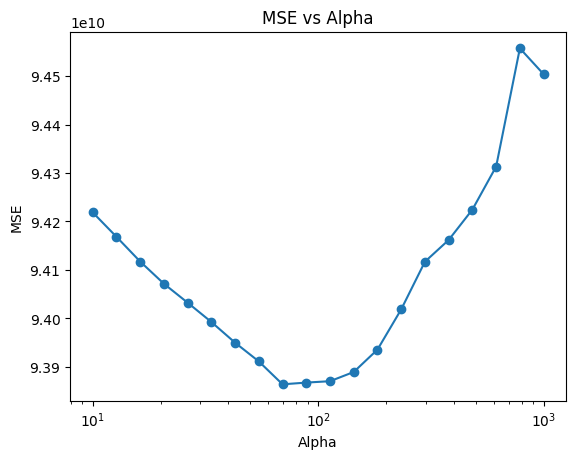

In [26]:
print('2.4')

plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=-1), marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('MSE vs Alpha')
plt.show()

2.5


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.435e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.874e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.221e+13

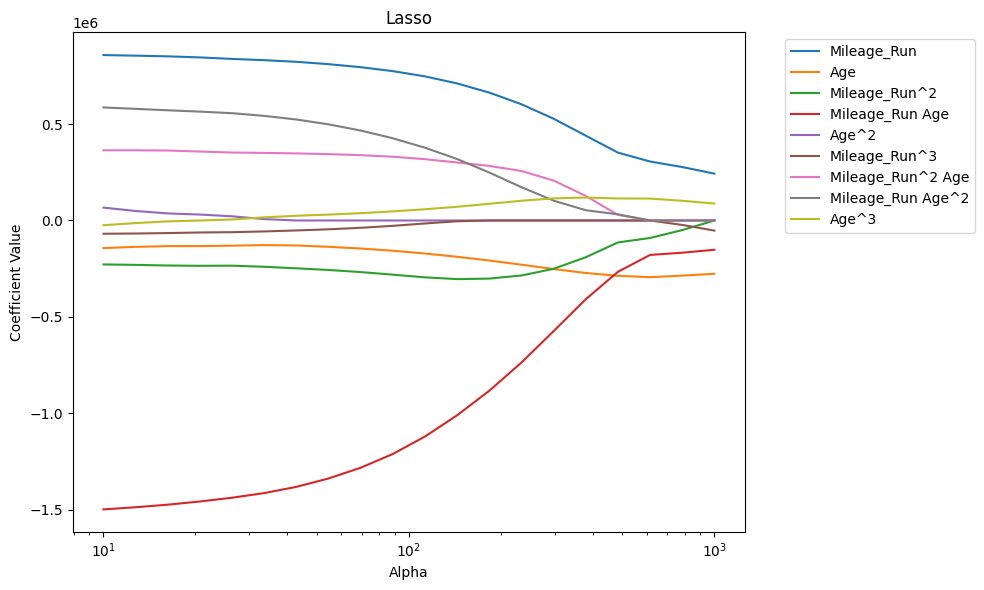

In [29]:
print('2.5')
alphas_path, coefs_path, _ = lasso_path(X_scaled, df['Price'], alphas=alphas_grid)

plt.figure(figsize=(10, 6))
for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i], label=feature_names[i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
print('2.6')

selected_features = feature_names[lasso_cv.coef_ != 0]
zeroed_features = feature_names[lasso_cv.coef_ == 0]
prop_zero = len(zeroed_features) / len(feature_names)

print(f"Selected features: {selected_features}")
print(f"Prop of features set to zero: {prop_zero:.2%}")

2.6
Selected features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
Prop of features set to zero: 0.00%


In [35]:
print('2.7')
comparison = pd.DataFrame({
    'Feature': feature_names,
    'OLS': ols.coef_,
    'LASSO': lasso_cv.coef_
})

comparison['Magnitude_Increase'] = np.abs(comparison['LASSO']) > np.abs(comparison['OLS'])
comparison['Sign_Change'] = np.sign(comparison['LASSO']) != np.sign(comparison['OLS'])
comparison.loc[comparison['LASSO'] == 0, 'Sign_Change'] = False

print(comparison)

2.7
             Feature           OLS          LASSO  Magnitude_Increase  \
0        Mileage_Run  9.117748e+05  611783.868767               False   
1                Age -2.481722e+05 -397507.787042                True   
2      Mileage_Run^2 -2.072926e+05 -519555.261867                True   
3    Mileage_Run Age -1.671212e+06 -473871.400459               False   
4              Age^2  3.505507e+05  230721.078724               False   
5      Mileage_Run^3 -6.514490e+04   97835.641353                True   
6  Mileage_Run^2 Age  3.388195e+05  318218.774588               False   
7  Mileage_Run Age^2  7.167816e+05  -35056.210190               False   
8              Age^3 -2.100379e+05   42493.187416               False   

   Sign_Change  
0        False  
1        False  
2        False  
3        False  
4        False  
5         True  
6        False  
7         True  
8         True  


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [40]:
print('3.1')

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

3.1


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [43]:
y = df['DEATH_EVENT']

cont_cols = ['age', 'ejection_fraction', 'serum_creatinine']
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(df[cont_cols])
cont_names = poly_cont.get_feature_names_out(cont_cols)

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

cat_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_int = poly_cat.fit_transform(df[cat_cols])
cat_names = poly_cat.get_feature_names_out(cat_cols)

X_final = np.hstack([X_cont_scaled, X_cat_int])
all_feature_names = np.concatenate([cont_names, cat_names])

In [45]:
print('3.2')
ols = LinearRegression()
ols.fit(X_final, y)

for name, coef in zip(all_feature_names[:3], ols.coef_[:3]):
    print(f"{name}: {coef:.4f}")

3.2
age: 1.5392
ejection_fraction: -2.1925
serum_creatinine: -0.8536


The sign for serum_creatinine is negative (-0.8536), which is counterintuitive because high levels of creatinine are deadly. This does not make sense bc a positive sign would be more deadly than a negative one. The model uses the conflicting signs to shape the regression line into a non-linear shape that fits the training data more precisely.

In [48]:
print('3.3')

alphas_grid = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas_grid, cv=20, max_iter=100000)
lasso_cv.fit(X_final, y)

print(f"Optimal Alpha: {lasso_cv.alpha_}")

3.3
Optimal Alpha: 0.005736152510448681


3.4


/var/folders/_b/jb39tkv126g9jr96b6bn1tzc0000gn/T/ipykernel_23680/2012236853.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


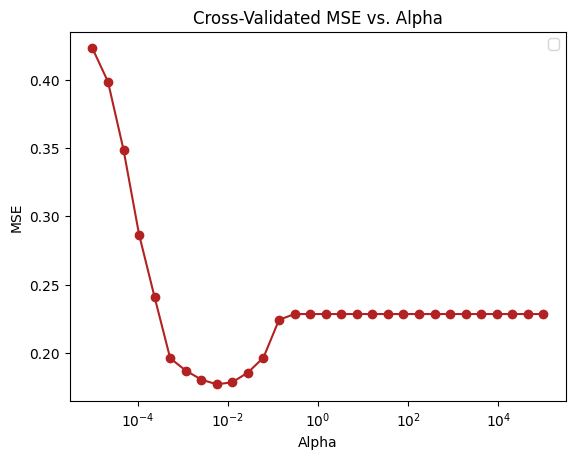

In [51]:
print('3.4')

mse_means = lasso_cv.mse_path_.mean(axis=-1)
plt.plot(lasso_cv.alphas_, mse_means, marker='o', color='firebrick')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Cross-Validated MSE vs. Alpha')
plt.legend()
plt.show()

3.5


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.335e-01, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.280e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.358e+00

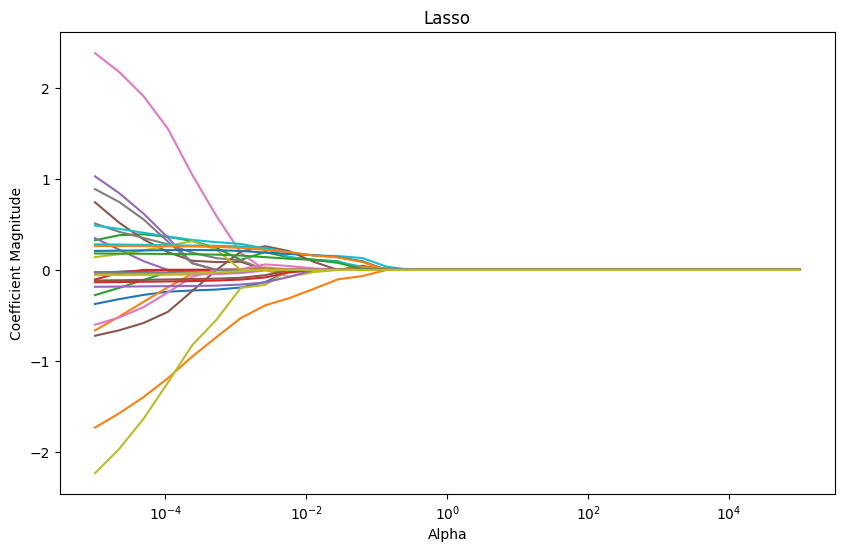

In [52]:
print('3.5')

alphas_path, coefs_path, _ = lasso_path(X_final, y, alphas=alphas_grid)

plt.figure(figsize=(10, 6))
for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Magnitude')
plt.title('Lasso')
plt.show()

In [55]:
print('3.6')

selected_mask = lasso_cv.coef_ != 0
selected_features = all_feature_names[selected_mask]
prop_zero = 1 - (np.sum(selected_mask) / len(all_feature_names))

print(f"Total features: {len(all_feature_names)}")
print(f"Features kept by LASSO: {len(selected_features)}")
print(f"Prop zeroed: {prop_zero:.2%}")

comparison = pd.DataFrame({
    'Feature': all_feature_names,
    'OLS_Coef': ols.coef_,
    'LASSO_Coef': lasso_cv.coef_
})

comparison['Magnitude_Increase'] = np.abs(comparison['LASSO_Coef']) > np.abs(comparison['OLS_Coef'])
comparison['Sign_Change'] = (np.sign(comparison['LASSO_Coef']) != np.sign(comparison['OLS_Coef'])) & (comparison['LASSO_Coef'] != 0)

print(comparison[comparison['LASSO_Coef'] != 0]) 

3.6
Total features: 29
Features kept by LASSO: 12
Prop zeroed: 58.62%
                                 Feature  OLS_Coef  LASSO_Coef  \
1                      ejection_fraction -2.192494   -0.329656   
2                       serum_creatinine -0.853588    0.116875   
9                                  age^3  1.993135    0.117992   
15                   ejection_fraction^3 -1.250341    0.204822   
16  ejection_fraction^2 serum_creatinine -1.270043    0.032801   
18                    serum_creatinine^3  0.072156   -0.043266   
19                               anaemia  0.008093    0.014178   
20                              diabetes -0.070705    0.000607   
21                   high_blood_pressure -0.007934    0.013608   
26          diabetes high_blood_pressure  0.132443    0.053968   
27                      diabetes smoking  0.156078    0.003466   
28           high_blood_pressure smoking  0.101455    0.017805   

    Magnitude_Increase  Sign_Change  
1                False        Fal

The Lasso model makes more sense because it has low variance and higher bias by adding the penalty. This model is much more stable bc of the low variance.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

4.1 

The objective function for this problem is to minimize the MSE plus a penalty term based on the square of the coefficients.

4.2 

with respect to $b_0$: $$\frac{\partial L}{\partial b_0} = \frac{-2}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0$$

$$\sum_{i=1}^n \tilde{y}_i - \sum_{i=1}^n b_0 - b_1 \sum_{i=1}^n \tilde{x}_i = 0$$

simplified: $$- (n \cdot b_0) = 0 \implies \mathbf{b_0 = 0} $$ 

with respect to $b_1$: $$\frac{\partial L}{\partial b_1} = \frac{-2}{n} \sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_0 - b_1 \tilde{x}_i) + 2\alpha b_1 = 0$$

use $b_0$ = 0 : $$-\frac{1}{n} \sum_{i=1}^n (\tilde{x}_i \tilde{y}_i - b_1 \tilde{x}_i^2) + \alpha b_1 = 0$$

$$\frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i = \frac{b_1}{n} \sum_{i=1}^n \tilde{x}_i^2 + \alpha b_1$$

$$\frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i = b_1 \left( \frac{1}{n} \sum_{i=1}^n \tilde{x}_i^2 + \alpha \right)$$

$$\mathbf{b_1^{Ridge} = \frac{\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n} \sum \tilde{x}_i^2 + \alpha}}$$


4.3 

As you increase $\alpha$, the denominator of the $b_1$ equation gets larger. This causes the magnitude of the slope coefficient $b_1$ to shrink toward zero.

4.4 

The issue with Lasso is that the absolute value of b1 is not differentiable at b1 = 0. This means that the derivative is harder to calculate bc there is no smooth curve as there would be with a ridge model. It is optimal to set the coefficient to zero when the correlation between the variable and  target is smaller than the set penalty.

###### (Citation: help from Google Gemini)